<a target="_blank" href="https://colab.research.google.com/github/cyneuro/Neural-Networks-Machine-Learning/blob/main/stats/Maximum_Likelihood_Estimation.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Week 5 - Fitting distributions and Maximum Likelihood Estimation (MLE)
#### 1. Get familiar with maximum likelihood estimation using the links in the module. Run the example notebook for MLE on gaussian distributed data Colab-example-MLE. Generate random data from the Logistic distribution. (choose your own μ and sand use np.random.logistic(...) for generation). Modify the code from the notebook to get estimates for μ and s on the generated data.



## Maximum Likelihood Estimation

This notebook assumes the data is a standard continuous normal distribution. The number of random samples, mean, and standard deviation of the distribution can be set in lines 7-9 in code cell 1.

The function `gaussian` calculates the negative log likelihood given the random samples and the initial predicted mean and standard deviations defined in initParams.

The key to the whole program is the scipy function `minimize`. It is a regular optimization function and more information about it can be found [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html).

**Note:** the method can be a lot of different options, all different mathematical optimization techniques.


#### Questions:
1. If everything is working, we would expect more accurate $\mu^*$ and $\sigma^*$ predictions with more random samples. Think about why this is.
2. What happens when the initial parameter guesses are extremely off? What about when they're extremely close? How does this impact the number of samples?
3. Break down each line in the `gaussian` function. Knowing what you know about MLE, what do you think the function `stats.norm.logpdf` does?

In [11]:
from scipy import stats
import numpy as np
from scipy.optimize import minimize
np.random.seed(1)

# Defaults are samples=100, mu=0, sigma=3
samples_norm = 100
mu_norm      = 0
sigma_norm   = 3

# Initialize parameters for logistic
samples_log  = 100
mu_log       = 0
sigma_log    = 3


#  Take random sample from the distribution of data (normal dist in this case)
sample_data_norm = np.random.normal(loc=mu_norm, scale=sigma_norm, size=samples_norm)
sample_data_log = np.random.logistic(loc=mu_log, scale=sigma_log, size=samples_log)

def gaussian(params):
    mean = params[0]
    sd = params[1]

    # Calculate negative log likelihood
    nll = -np.sum(stats.norm.logpdf(sample_data, loc=mean, scale=sd))

    return nll


initParams = [1, 1]
results_norm = minimize(gaussian, initParams, method='Nelder-Mead')
results_log = minimize(gaussian, initParams, method='Nelder-Mead')


print('(Normal Distribution) mean*  = {:.3f} std*  = {:.3f}'.format(results_norm.x[0],results_norm.x[1]))
print('(Normal Distribution) mean   = {:.3f} std   = {:.3f}'.format(mu_norm, sigma_norm))

print('(Logistic Distribution) mean*  = {:.3f} std*  = {:.3f}'.format(results_norm.x[0],results_norm.x[1]))
print('(Logistic Distribution) mean   = {:.3f} std   = {:.3f}'.format(mu_norm, sigma_norm))

(Normal Distribution) mean*  = 1.682 std*  = 2.656
(Normal Distribution) mean   = 0.000 std   = 3.000
(Logistic Distribution) mean*  = 1.682 std*  = 2.656
(Logistic Distribution) mean   = 0.000 std   = 3.000


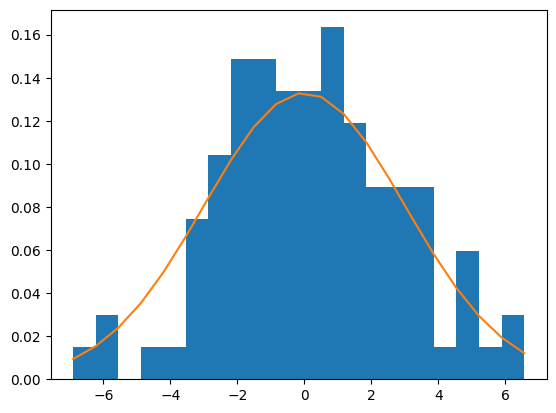

In [9]:
import matplotlib.pyplot as plt

def normal_dist(inp, mean, std):
    return 1./(np.sqrt(2.*np.pi)*std)*np.exp(-np.power((inp - mean)/std, 2.)/2)

x = np.arange(-10, 10, 0.1)
y = normal_dist(x, mu_norm, sigma_norm)

num_bins = 20

count, bins, ignored = plt.hist(sample_data_norm, bins=num_bins, density=True)
plt.plot(bins, 1/(sigma_norm * np.sqrt(2 * np.pi)) * np.exp( - (bins - mu_norm)**2 / (2 * sigma_norm**2) ))
plt.show()

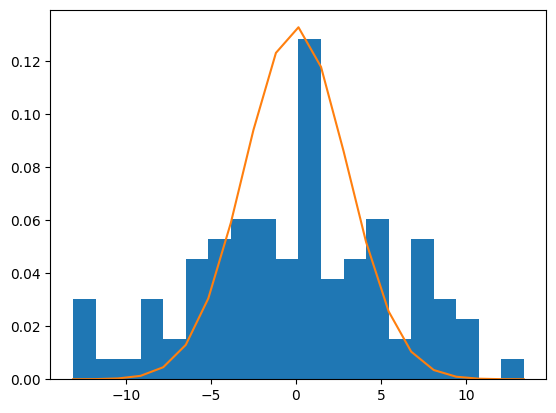

In [10]:
x = np.arange(-10, 10, 0.1)
y = normal_dist(x, mu_log, sigma_log)

num_bins = 20

count, bins, ignored = plt.hist(sample_data_log, bins=num_bins, density=True)
plt.plot(bins, 1/(sigma_log * np.sqrt(2 * np.pi)) * np.exp( - (bins - mu_log)**2 / (2 * sigma_log**2) ))
plt.show()